<a href="https://colab.research.google.com/github/angeruzzi/home-credit-default-risk/blob/main/notebooks/01_problem_and_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home Credit Default Risk: Definição do Problema e Entendimento dos Dados

## Introdução

A avaliação do risco de crédito é uma etapa fundamental do processo de concessão.
Antes de conceder uma operação, as instituições financeiras precisam estimar a
probabilidade de que um solicitante apresente dificuldades de pagamento e
determinar como essa informação será utilizada no processo decisório.

Este projeto desenvolve um modelo de **Application Score para pessoas físicas**
utilizando os dados da competição
[Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk).
O objetivo é estimar, no momento da solicitação, a probabilidade de que um
cliente apresente dificuldades de pagamento.

Serão desenvolvidas e comparadas duas abordagens de modelagem:

1. uma abordagem tradicional de credit scoring, baseada em discretização,
   Weight of Evidence (WoE), Information Value (IV) e Regressão Logística;
2. um modelo challenger de Machine Learning baseado em LightGBM, complementado
   por explicabilidade com SHAP.

Os modelos serão avaliados não apenas pela capacidade de ordenar os solicitantes
por nível de risco, mas também pela qualidade das probabilidades estimadas. As
principais dimensões de avaliação incluem discriminação, calibração,
estabilidade e interpretabilidade, além da aplicação dos resultados em
simulações de políticas de crédito.

O modelo não será responsável pela decisão final de concessão. Sua saída será
uma probabilidade de dificuldade de pagamento e um score de risco correspondente,
que poderão apoiar a área de Política de Crédito na definição de pontos de
corte, faixas de risco, regras de aprovação e estratégias de carteira.

### 1. Contexto de Negócio

A concessão de crédito envolve um equilíbrio entre crescimento e controle de
risco. Políticas excessivamente restritivas podem reduzir as perdas decorrentes
da inadimplência, mas também diminuem a taxa de aprovação, limitam a geração de
receita e podem excluir clientes com capacidade de pagamento. Por outro lado,
políticas muito permissivas podem ampliar o volume concedido, mas elevar a
inadimplência e comprometer a rentabilidade da carteira.

Nesse contexto, o **Application Score** é utilizado para estimar o risco de um
solicitante no momento da proposta de crédito. A partir das informações
disponíveis na solicitação e do histórico de crédito anterior, o modelo produz
uma probabilidade de dificuldade de pagamento e ordena os clientes segundo seu
nível estimado de risco.

A estimativa produzida pelo modelo é um dos insumos para a Política de Crédito.
Ela pode ser combinada com regras de elegibilidade, capacidade de pagamento,
valor solicitado, limites de exposição, garantias, precificação e apetite a
risco da instituição.

Portanto, o modelo de risco não determina isoladamente se o crédito será
concedido. Sua função é fornecer uma medida consistente de risco para apoiar a
definição de pontos de corte, faixas de risco e estratégias de concessão.

### 2. Definição do Problema

Este projeto trata de um problema de **classificação binária supervisionada**
aplicado à avaliação de risco de crédito para pessoas físicas.

A partir das informações disponíveis no momento da solicitação — incluindo
dados cadastrais, características financeiras, informações externas de crédito
e histórico de relacionamentos anteriores — busca-se estimar a probabilidade de
que o solicitante apresente dificuldades de pagamento no contrato concedido.

A variável-alvo `TARGET` assume dois valores:

- `TARGET = 1`: cliente que apresentou dificuldade de pagamento, conforme a
  definição adotada pela Home Credit;
- `TARGET = 0`: cliente que não apresentou o evento definido pela Home Credit.

Formalmente, o modelo buscará estimar:

$$
P(\mathrm{TARGET}=1 \mid X)
$$

em que \(X\) representa o conjunto de variáveis disponíveis para o solicitante
no momento da análise de crédito.

A saída principal será, portanto, uma probabilidade estimada de dificuldade de
pagamento. Posteriormente, essa probabilidade será convertida em um score no
qual valores maiores representarão menor risco, facilitando sua interpretação e
utilização pela área de Política de Crédito.

O modelo também deverá ser capaz de ordenar adequadamente os solicitantes por
nível de risco e produzir probabilidades coerentes com as taxas observadas.
Esses dois aspectos serão avaliados separadamente:

- **discriminação:** capacidade de diferenciar e ordenar clientes de maior e
  menor risco;
- **calibração:** correspondência entre as probabilidades estimadas e a
  frequência observada do evento.

A escolha de um ponto de corte para aprovação não faz parte do problema
estatístico isoladamente. Essa definição será tratada posteriormente como uma
decisão de Política de Crédito, condicionada ao apetite a risco, à taxa de
aprovação desejada, à perda esperada e à rentabilidade da carteira.

#### 2.1 Interpretação da Variável-Alvo

Embora a competição seja denominada *Home Credit Default Risk*, a variável
`TARGET` não deve ser interpretada automaticamente como uma definição
regulatória de default.

Segundo a descrição disponibilizada pela Home Credit:

- `TARGET = 1` representa o cliente que apresentou dificuldade de pagamento,
  caracterizada por atraso superior a determinada quantidade de dias em pelo
  menos uma das primeiras parcelas do empréstimo;
- `TARGET = 0` representa os demais clientes.

A documentação pública, entretanto, não informa precisamente o número de dias
de atraso considerado nem a extensão da janela utilizada para observar o
comportamento de pagamento.

Por esse motivo, a saída do modelo será interpretada como **probabilidade de
dificuldade de pagamento conforme a definição da Home Credit**, e não como uma
Probability of Default (PD) regulatória com horizonte conhecido.

Essa distinção é importante porque uma definição formal de default deve
especificar, no mínimo:

- o evento que caracteriza o cliente como mau pagador;
- a quantidade de dias de atraso considerada;
- a data de referência da análise;
- a janela de observação das variáveis explicativas;
- a janela de performance na qual o evento é observado.

No contexto deste projeto, esses elementos serão documentados da seguinte forma:

| Elemento | Definição adotada |
|---|---|
| População | Pessoas físicas que solicitaram crédito à Home Credit |
| Unidade de análise | Uma solicitação de crédito identificada por `SK_ID_CURR` |
| Momento da avaliação | Momento da solicitação de crédito |
| Evento de interesse | Dificuldade de pagamento indicada por `TARGET = 1` |
| Não evento | Demais solicitações, indicadas por `TARGET = 0` |
| Janela de observação | Informações disponíveis antes ou no momento da solicitação |
| Janela de performance | Não informada precisamente pela documentação pública |
| Saída do modelo | Probabilidade estimada de `TARGET = 1` |

Consequentemente, expressões como *risco de pagamento*, *probabilidade de
dificuldade de pagamento* e *evento-alvo* serão preferidas ao longo do projeto.
O termo default poderá ser utilizado ao fazer referência ao nome da competição
ou de forma genérica, sempre considerando essa limitação.

### 3. Objetivos

#### 3.1 Objetivo Geral

Desenvolver, avaliar e comparar modelos de risco de crédito capazes de estimar
a probabilidade de dificuldade de pagamento de solicitantes pessoas físicas,
transformando as probabilidades estimadas em um score e em faixas de risco que
possam apoiar decisões de Política de Crédito.

#### 3.2 Objetivos Específicos

1. Compreender a população, a variável-alvo e as diferentes fontes de dados
   disponibilizadas pela Home Credit.

2. Avaliar a qualidade dos dados, identificando valores ausentes, anomalias,
   outliers, inconsistências, desbalanceamento da variável-alvo e possíveis
   fontes de data leakage.

3. Desenvolver variáveis relacionadas à capacidade financeira, características
   da operação, histórico de crédito e comportamento de pagamento.

4. Construir um modelo tradicional de credit scoring utilizando binning,
   Weight of Evidence (WoE), Information Value (IV) e Logistic Regression.

5. Construir um modelo challenger utilizando LightGBM, capaz de representar
   relações não lineares e interações entre as variáveis.

6. Comparar os modelos em termos de discriminação, calibração, estabilidade e
   interpretabilidade, utilizando métricas adequadas ao contexto de crédito.

7. Utilizar coeficientes, WoE, feature importance e SHAP para compreender os
   principais fatores associados ao risco estimado.

8. Converter a probabilidade estimada em um score crescente, no qual valores
   maiores representem menor risco, e segmentar os clientes em faixas de risco.

9. Simular diferentes pontos de corte e analisar seus efeitos sobre taxa de
   aprovação, taxa observada de dificuldade de pagamento, perda esperada e
   rentabilidade estimada.

10. Demonstrar o monitoramento da estabilidade das variáveis e do score por
    meio do Population Stability Index (PSI) e de cenários simulados de drift.

### 4. Escopo do Projeto

Este projeto concentra-se no desenvolvimento de um **Application Score para
pessoas físicas**, utilizando informações disponíveis antes ou no momento da
solicitação de crédito.

O escopo contempla:

- entendimento da população e da definição da variável-alvo;
- análise exploratória e avaliação da qualidade dos dados;
- identificação de anomalias, valores ausentes e possíveis fontes de
  data leakage;
- engenharia de variáveis a partir dos dados cadastrais, financeiros, de bureau
  e do histórico de crédito;
- desenvolvimento de um modelo tradicional de credit scoring com binning,
  Weight of Evidence (WoE), Information Value (IV) e Logistic Regression;
- desenvolvimento de um modelo challenger utilizando LightGBM;
- avaliação de discriminação, calibração, estabilidade e interpretabilidade;
- explicabilidade global e individual por meio de coeficientes, WoE, feature
  importance e SHAP;
- conversão da probabilidade estimada em score e faixas de risco;
- simulação de pontos de corte e análise de seus impactos sobre indicadores de
  risco e negócio;
- demonstração do monitoramento de variáveis e scores por meio do Population
  Stability Index (PSI).

Não fazem parte do escopo:

- desenvolvimento de Behavior Score ou Collection Score;
- definição de limites individuais de crédito;
- modelagem independente de Loss Given Default (LGD) e Exposure at Default
  (EAD);
- cálculo regulatório de capital ou provisão;
- construção de uma Probability of Default regulatória;
- inferência causal dos efeitos da concessão;
- implantação do modelo em produção;
- desenvolvimento de API, interface operacional ou infraestrutura de serving.

Quando métricas como perda esperada e rentabilidade forem utilizadas nas
simulações de Política de Crédito, os parâmetros necessários que não estiverem
disponíveis na base serão tratados como premissas simuladas e identificados
explicitamente.

Essa delimitação permite aprofundar o ciclo de desenvolvimento, avaliação e
utilização de um Application Score sem atribuir aos dados conclusões que eles
não permitem sustentar.

### 5. Estrutura de Modelagem

O projeto utilizará uma estrutura comparativa entre um modelo tradicional de
credit scoring e um modelo challenger de Machine Learning.

| Componente | Modelo tradicional | Modelo challenger |
|---|---|---|
| Algoritmo | Logistic Regression | LightGBM |
| Tratamento das variáveis | Binning e Weight of Evidence | Variáveis originais e derivadas |
| Seleção de variáveis | Information Value, correlação, estabilidade e análise de negócio | Validação, feature importance e SHAP |
| Relações não lineares | Representadas pelos bins | Aprendidas pelas árvores |
| Interações entre variáveis | Precisam ser especificadas | Podem ser aprendidas pelo modelo |
| Interpretabilidade global | WoE e coeficientes | Feature importance e SHAP |
| Interpretabilidade individual | Contribuição para o score | Valores SHAP |
| Saída principal | Probabilidade estimada de dificuldade de pagamento | Probabilidade estimada de dificuldade de pagamento |

A Logistic Regression será utilizada como modelo de referência por sua tradição
em credit scoring, transparência, facilidade de documentação e possibilidade de
construção de um scorecard interpretável.

O LightGBM será desenvolvido como modelo challenger, buscando verificar se a
representação de relações não lineares e interações entre variáveis proporciona
ganhos relevantes em relação ao modelo tradicional.

Os modelos serão treinados e avaliados sobre as mesmas populações sempre que
tecnicamente possível. A comparação considerará:

- ROC-AUC, Gini, KS e PR-AUC para discriminação;
- Brier Score, Log Loss e calibration curve para calibração;
- resultados nas amostras de treino, validação e teste;
- taxa observada do evento por decil e faixa de risco;
- estabilidade das variáveis e dos scores;
- interpretabilidade global e individual;
- complexidade e facilidade de governança;
- impactos simulados sobre indicadores de Política de Crédito.

O modelo challenger não será escolhido automaticamente por apresentar a maior
ROC-AUC. Sua adoção dependerá de ganhos consistentes, avaliados em conjunto com
calibração, estabilidade, interpretabilidade e utilidade para o negócio.

Após a comparação, o modelo que apresentar o melhor equilíbrio entre essas
dimensões poderá ser selecionado como o modelo principal do projeto.

### 6. Modelo de Crédito e Política de Crédito

O modelo de crédito e a Política de Crédito desempenham funções relacionadas,
mas distintas, no processo de concessão.

O modelo transforma as informações disponíveis sobre o solicitante em uma
estimativa de risco:

$$
\text{Dados do solicitante}
\rightarrow
\text{Probabilidade estimada}
\rightarrow
\text{Score de risco}
$$

A Política de Crédito utiliza essa estimativa em conjunto com critérios de
negócio para definir a decisão:

$$
\text{Score}
+
\text{Regras de negócio}
+
\text{Capacidade de pagamento}
+
\text{Limites}
\rightarrow
\text{Decisão de crédito}
$$

Assim, o modelo será responsável por:

- estimar a probabilidade de dificuldade de pagamento;
- ordenar os solicitantes por nível de risco;
- produzir um score consistente e interpretável;
- segmentar os clientes em faixas de risco;
- fornecer informações que apoiem a definição da política.

A Política de Crédito poderá combinar o score com outros elementos, como:

- critérios mínimos de elegibilidade;
- comprometimento de renda;
- valor e prazo da operação;
- exposição total do cliente;
- garantias disponíveis;
- custo de capital;
- precificação;
- apetite a risco;
- restrições regulatórias e operacionais.

Portanto, o modelo não aprovará nem rejeitará automaticamente uma solicitação.
A definição do cutoff é uma decisão de negócio que representa um trade-off
entre aprovação, risco e retorno.

Um cutoff mais permissivo tende a produzir:

- maior taxa de aprovação;
- maior volume concedido;
- maior receita potencial;
- maior exposição a clientes de risco elevado;
- maior taxa esperada de dificuldade de pagamento.

Um cutoff mais restritivo tende a produzir:

- menor taxa de aprovação;
- menor volume concedido;
- menor exposição ao risco;
- menor perda esperada;
- possível redução da receita e da rentabilidade total.

Nas etapas finais do projeto, diferentes cutoffs serão simulados para demonstrar
esses trade-offs. A seleção de uma política não será baseada apenas em métricas
estatísticas como accuracy, ROC-AUC ou KS, mas também em indicadores de negócio,
como taxa de aprovação, bad rate, perda esperada e rentabilidade estimada.

### 7. Limitações Metodológicas

A interpretação dos resultados deve considerar as limitações da base Home
Credit e do desenho deste projeto.

#### 7.1 Definição incompleta do evento-alvo

A documentação pública não informa precisamente o número de dias de atraso nem
a extensão da janela de performance utilizada para definir `TARGET = 1`.

Consequentemente, a probabilidade estimada não será apresentada como uma
Probability of Default regulatória ou como uma PD de 12 meses. Ela representa a
probabilidade do evento de dificuldade de pagamento definido pela Home Credit.


#### 7.2 Ausência de uma referência temporal confiável

A base de aplicações atuais não fornece uma data-calendário adequada para
organizar os contratos cronologicamente. Por isso, não será possível construir
uma validação Out-of-Time genuína.

O projeto utilizará amostras estratificadas de treino, validação e teste. A
análise de estabilidade temporal será demonstrada por meio de cenários simulados
de drift, e essa limitação será explicitamente registrada.

#### 7.3 Viés de seleção e ausência dos rejeitados

Os clientes presentes na base com resultado de pagamento observado passaram
pelo processo de concessão adotado pela instituição. Não há uma amostra
identificada de propostas rejeitadas com comportamento posterior conhecido.

Assim, o modelo aprenderá a partir da população historicamente aceita e poderá
não representar adequadamente todos os solicitantes que chegariam à instituição.
Esse problema é conhecido no mercado de crédito como **reject inference** ou
viés decorrente da ausência de desempenho dos rejeitados.

Nenhuma técnica de reject inference será aplicada neste projeto, pois a base não
oferece informações suficientes para validar adequadamente esse procedimento.

#### 7.4 Dados anonimizados e contexto de origem

A base representa uma população histórica e anonimizada de uma instituição
específica. Algumas variáveis e categorias possuem descrição limitada, e os
dados não devem ser considerados representativos do mercado de crédito
brasileiro sem uma análise adicional.

Os resultados obtidos demonstram uma metodologia de modelagem, mas não devem ser
transferidos diretamente para outra instituição, produto ou população.

#### 7.5 Disponibilidade temporal das variáveis

Somente informações disponíveis antes ou no momento da solicitação devem ser
utilizadas pelo Application Score.

As tabelas históricas serão analisadas para identificar registros ou variáveis
que possam conter informações posteriores à data da aplicação. Qualquer
informação que antecipe direta ou indiretamente o resultado será considerada
data leakage e deverá ser removida.

#### 7.6 Ausência de LGD e EAD observadas

A base não fornece eventos e horizontes suficientes para desenvolver e validar
modelos independentes de Loss Given Default (LGD) e Exposure at Default (EAD).

Quando a perda esperada for utilizada nas simulações, será calculada por:

$$
EL = PD \times LGD \times EAD
$$

Os valores de LGD e EAD serão tratados como premissas simplificadas e
explicitamente identificados como simulados.

#### 7.7 Limitações da simulação de Política de Crédito

As simulações de cutoff não reproduzem integralmente uma política real, pois não
incorporam todos os custos, receitas, restrições operacionais, efeitos de
seleção, mudanças de comportamento ou respostas dos clientes à concessão.

Portanto, os resultados serão utilizados para demonstrar os trade-offs entre
aprovação, risco e retorno, e não como recomendação real de concessão.

### 8. Objetivos deste Notebook

Este primeiro notebook estabelece a base conceitual, metodológica e estrutural
do projeto. Seus objetivos são:

- definir o problema de negócio e o evento que será modelado;
- documentar a população, a unidade de análise e a variável-alvo;
- delimitar o escopo e as limitações metodológicas;
- configurar o ambiente de execução e o cache opcional no Google Drive;
- obter os dados da competição a partir da fonte oficial;
- inventariar os arquivos e compreender o papel de cada tabela;
- identificar as chaves utilizadas nos relacionamentos entre as fontes;
- avaliar inicialmente dimensões, tipos de dados, duplicidades e integridade
  das chaves;
- caracterizar a distribuição da variável-alvo;
- registrar decisões que deverão ser respeitadas nas etapas posteriores.

A análise exploratória detalhada das variáveis, incluindo missing values,
anomalias, outliers, distribuições e relações com o evento-alvo, será realizada
no notebook seguinte.

Ao final desta etapa, espera-se obter uma visão clara sobre:

1. o que o modelo pretende estimar;
2. qual é a população utilizada;
3. quais informações estão disponíveis;
4. como as tabelas se relacionam;
5. quais limitações condicionam a interpretação dos resultados;
6. quais dados poderão seguir para a análise exploratória e a engenharia de
   variáveis.

## Configuração do Ambiente

Nesta seção, o ambiente de execução será identificado e o diretório raiz do
projeto será configurado.

Quando executado no Google Colab, o repositório será clonado para o
armazenamento temporário da sessão. Em uma execução local, considera-se que o
usuário já clonou o repositório e abriu o notebook a partir da estrutura do
projeto.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

REPOSITORY_URL = (
    "https://github.com/angeruzzi/home-credit-default-risk.git"
)

if IN_COLAB:
    PROJECT_ROOT = Path("/content/home-credit-default-risk")

    if not (PROJECT_ROOT / ".git").exists():
        subprocess.run(
            [
                "git",
                "clone",
                REPOSITORY_URL,
                str(PROJECT_ROOT),
            ],
            check=True,
        )

else:
    current_directory = Path.cwd().resolve()

    if current_directory.name == "notebooks":
        PROJECT_ROOT = current_directory.parent
    else:
        PROJECT_ROOT = current_directory

os.chdir(PROJECT_ROOT)

print(f"Google Colab: {IN_COLAB}")
print(f"Diretório do projeto: {PROJECT_ROOT}")
print(f"Versão do Python: {sys.version.split()[0]}")

Google Colab: True
Diretório do projeto: /content/home-credit-default-risk
Versão do Python: 3.13.15


In [2]:
expected_directories = [
    "artifacts",
    "data",
    "docs",
    "notebooks",
    "reports",
]

missing_directories = [
    directory
    for directory in expected_directories
    if not (PROJECT_ROOT / directory).is_dir()
]

if missing_directories:
    raise FileNotFoundError(
        "Diretórios esperados não encontrados: "
        + ", ".join(missing_directories)
    )

print("Estrutura do projeto localizada com sucesso.")

Estrutura do projeto localizada com sucesso.


### Cache Persistente no Google Drive

O armazenamento do Google Colab é temporário e seus arquivos são removidos
quando a sessão é encerrada. Para evitar downloads e processamentos repetidos,
o Google Drive será utilizado como cache persistente para dados e artefatos de
modelagem.

O uso do Drive é opcional. Quando desabilitado ou quando o notebook é executado
localmente, os diretórios do próprio repositório são utilizados. Dessa forma, o
projeto permanece reproduzível por terceiros sem depender de uma estrutura
pessoal do Google Drive.

In [3]:
USE_GOOGLE_DRIVE_CACHE = True

if IN_COLAB and USE_GOOGLE_DRIVE_CACHE:
    from google.colab import drive

    drive.mount("/content/drive")

    CACHE_ROOT = Path(
        "/content/drive/MyDrive/home-credit-default-risk"
    )

    DATA_ROOT = CACHE_ROOT / "data"
    ARTIFACTS_ROOT = CACHE_ROOT / "artifacts"

    cache_mode = "Google Drive"

else:
    DATA_ROOT = PROJECT_ROOT / "data"
    ARTIFACTS_ROOT = PROJECT_ROOT / "artifacts"

    cache_mode = "armazenamento local"

REPORTS_ROOT = PROJECT_ROOT / "reports"
DOCS_ROOT = PROJECT_ROOT / "docs"

print(f"Modo de armazenamento: {cache_mode}")
print(f"Dados: {DATA_ROOT}")
print(f"Artefatos: {ARTIFACTS_ROOT}")
print(f"Relatórios: {REPORTS_ROOT}")

Mounted at /content/drive
Modo de armazenamento: Google Drive
Dados: /content/drive/MyDrive/home-credit-default-risk/data
Artefatos: /content/drive/MyDrive/home-credit-default-risk/artifacts
Relatórios: /content/home-credit-default-risk/reports


In [4]:
DATA_RAW_DIR = DATA_ROOT / "raw"
DATA_INTERIM_DIR = DATA_ROOT / "interim"
DATA_PROCESSED_DIR = DATA_ROOT / "processed"

MODELS_DIR = ARTIFACTS_ROOT / "models"
PREPROCESSING_DIR = ARTIFACTS_ROOT / "preprocessing"
METADATA_DIR = ARTIFACTS_ROOT / "metadata"

FIGURES_DIR = REPORTS_ROOT / "figures"
TABLES_DIR = REPORTS_ROOT / "tables"

PROJECT_DIRECTORIES = [
    DATA_RAW_DIR,
    DATA_INTERIM_DIR,
    DATA_PROCESSED_DIR,
    MODELS_DIR,
    PREPROCESSING_DIR,
    METADATA_DIR,
    FIGURES_DIR,
    TABLES_DIR,
]

for directory in PROJECT_DIRECTORIES:
    directory.mkdir(parents=True, exist_ok=True)

print("Diretórios configurados com sucesso.")

Diretórios configurados com sucesso.


In [5]:
directories = {
    "Dados originais": DATA_RAW_DIR,
    "Dados intermediários": DATA_INTERIM_DIR,
    "Dados processados": DATA_PROCESSED_DIR,
    "Modelos": MODELS_DIR,
    "Pré-processamento": PREPROCESSING_DIR,
    "Metadados": METADATA_DIR,
    "Figuras": FIGURES_DIR,
    "Tabelas": TABLES_DIR,
}

for name, path in directories.items():
    print(f"{name:<22} → {path}")

Dados originais        → /content/drive/MyDrive/home-credit-default-risk/data/raw
Dados intermediários   → /content/drive/MyDrive/home-credit-default-risk/data/interim
Dados processados      → /content/drive/MyDrive/home-credit-default-risk/data/processed
Modelos                → /content/drive/MyDrive/home-credit-default-risk/artifacts/models
Pré-processamento      → /content/drive/MyDrive/home-credit-default-risk/artifacts/preprocessing
Metadados              → /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata
Figuras                → /content/home-credit-default-risk/reports/figures
Tabelas                → /content/home-credit-default-risk/reports/tables


### Dependências e Bibliotecas

As dependências do projeto são declaradas no arquivo `requirements.txt`,
permitindo que o ambiente seja reconstruído por outros usuários.

Nesta etapa serão utilizadas apenas bibliotecas relacionadas à manipulação de
dados, leitura dos arquivos e inspeção inicial. As bibliotecas específicas de
modelagem serão utilizadas nos notebooks correspondentes.

In [6]:
REQUIREMENTS_PATH = PROJECT_ROOT / "requirements.txt"

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {REQUIREMENTS_PATH}"
    )

if REQUIREMENTS_PATH.stat().st_size == 0:
    print("O arquivo requirements.txt está vazio.")
else:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "-r",
            str(REQUIREMENTS_PATH),
        ],
        check=True,
    )

    print("Dependências instaladas com sucesso.")

O arquivo requirements.txt está vazio.


In [7]:
import json
import platform
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(
    style="whitegrid",
    palette="deep",
)

RANDOM_STATE = 42

In [8]:
environment_versions = {
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "Matplotlib": plt.matplotlib.__version__,
    "Seaborn": sns.__version__,
}

display(
    pd.DataFrame(
        environment_versions.items(),
        columns=["Componente", "Versão"],
    )
)

,Componente,Versão
0,Python,3.13.15
1,NumPy,2.1.3
2,Pandas,2.2.3
3,Matplotlib,3.10.0
4,Seaborn,0.13.2


## Obtenção dos Dados

Os dados utilizados neste projeto são fornecidos pela competição
[Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk).

Os arquivos não são distribuídos neste repositório. Para reproduzir o projeto,
cada usuário deverá:

1. possuir uma conta no Kaggle;
2. aceitar as regras da competição;
3. gerar sua própria credencial da API;
4. executar o download pela fonte oficial.

Quando todos os arquivos já estiverem disponíveis no cache, o download será
ignorado.

In [9]:
EXPECTED_RAW_FILES = [
    "application_train.csv",
    "application_test.csv",
    "bureau.csv",
    "bureau_balance.csv",
    "previous_application.csv",
    "POS_CASH_balance.csv",
    "credit_card_balance.csv",
    "installments_payments.csv",
    "HomeCredit_columns_description.csv",
    "sample_submission.csv",
]

missing_raw_files = [
    filename
    for filename in EXPECTED_RAW_FILES
    if not (DATA_RAW_DIR / filename).exists()
]

if missing_raw_files:
    print(
        f"{len(missing_raw_files)} arquivo(s) ainda não encontrado(s):"
    )

    for filename in missing_raw_files:
        print(f"  - {filename}")

else:
    print("Todos os arquivos originais estão disponíveis no cache.")

Todos os arquivos originais estão disponíveis no cache.


### Autenticação no Kaggle

O download pela API do Kaggle requer o arquivo pessoal `kaggle.json`.

No Google Colab, quando os dados ainda não estiverem disponíveis, será
solicitado o envio temporário dessa credencial. O arquivo será armazenado apenas
no ambiente da sessão e não será enviado ao GitHub ou salvo no cache do Google
Drive.

Para obter o arquivo no Kaggle:

*   acesse as configurações da sua conta;
*   localize a seção da API;
*   selecione a opção para criar um novo token;
*   salve o arquivo kaggle.json em seu computador.

In [11]:
# if KAGGLE_CREDENTIAL_PATH.exists():
#     KAGGLE_CREDENTIAL_PATH.unlink()
#     print("Credencial anterior removida.")

KAGGLE_CREDENTIAL_PATH = (
    Path.home() / ".kaggle" / "kaggle.json"
)

if missing_raw_files and not KAGGLE_CREDENTIAL_PATH.exists():

    if IN_COLAB:
        from google.colab import files

        print("Selecione seu arquivo kaggle.json.")
        uploaded_files = files.upload()

        if "kaggle.json" not in uploaded_files:
            raise FileNotFoundError(
                "O arquivo kaggle.json não foi enviado."
            )

        KAGGLE_CREDENTIAL_PATH.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        uploaded_credential_path = (
            PROJECT_ROOT / "kaggle.json"
        )

        uploaded_credential_path.replace(
            KAGGLE_CREDENTIAL_PATH
        )

        os.chmod(
            KAGGLE_CREDENTIAL_PATH,
            0o600,
        )

        print("Credencial do Kaggle configurada.")

    else:
        raise FileNotFoundError(
            "Credencial do Kaggle não encontrada. "
            "Configure o arquivo ~/.kaggle/kaggle.json."
        )

elif not missing_raw_files:
    print(
        "Autenticação dispensada: os dados já estão no cache."
    )

else:
    print("Credencial do Kaggle encontrada.")

Autenticação dispensada: os dados já estão no cache.


### Download e Extração

O conjunto completo será baixado apenas quando algum dos arquivos obrigatórios
não estiver disponível.

Após o download, o arquivo compactado será extraído para o diretório `raw`. Os
arquivos originais permanecerão sem alterações para preservar a rastreabilidade
da fonte.

In [12]:
COMPETITION_NAME = "home-credit-default-risk"

DATASET_ZIP_PATH = (
    DATA_RAW_DIR / f"{COMPETITION_NAME}.zip"
)

if missing_raw_files:
    print("Iniciando download dos dados...")

    subprocess.run(
        [
            "kaggle",
            "competitions",
            "download",
            "-c",
            COMPETITION_NAME,
            "-p",
            str(DATA_RAW_DIR),
        ],
        check=True,
    )

    print("Extraindo os arquivos...")

    with zipfile.ZipFile(DATASET_ZIP_PATH, "r") as zip_file:
        zip_file.extractall(DATA_RAW_DIR)

    print("Download e extração concluídos.")

else:
    print(
        "Download ignorado: dados encontrados no cache."
    )

Download ignorado: dados encontrados no cache.


In [13]:
missing_raw_files = [
    filename
    for filename in EXPECTED_RAW_FILES
    if not (DATA_RAW_DIR / filename).exists()
]

if missing_raw_files:
    raise FileNotFoundError(
        "O conjunto de dados está incompleto. "
        "Arquivos ausentes: "
        + ", ".join(missing_raw_files)
    )

print(
    f"Conjunto validado: {len(EXPECTED_RAW_FILES)} "
    "arquivos obrigatórios encontrados."
)

Conjunto validado: 10 arquivos obrigatórios encontrados.


## Inventário dos Dados

A competição disponibiliza diferentes fontes relacionadas às solicitações de
crédito atuais e ao histórico de relacionamento dos clientes.

Antes de carregar integralmente as tabelas, será construído um inventário com:

- nome do arquivo;
- finalidade da fonte;
- tamanho em disco;
- quantidade de registros;
- quantidade de colunas;
- principais chaves de relacionamento.

Essa etapa permite compreender o volume, a granularidade e o papel de cada
fonte no projeto.

In [14]:
DATA_SOURCE_METADATA = {
    "application_train.csv": {
        "fonte": "Aplicações de desenvolvimento",
        "descricao": (
            "Dados da solicitação atual com a variável TARGET."
        ),
        "chaves": "SK_ID_CURR",
    },
    "application_test.csv": {
        "fonte": "Aplicações da competição",
        "descricao": (
            "Dados da solicitação atual sem a variável TARGET."
        ),
        "chaves": "SK_ID_CURR",
    },
    "bureau.csv": {
        "fonte": "Bureau de crédito",
        "descricao": (
            "Créditos anteriores do cliente registrados em "
            "outras instituições."
        ),
        "chaves": "SK_ID_CURR, SK_ID_BUREAU",
    },
    "bureau_balance.csv": {
        "fonte": "Histórico mensal do bureau",
        "descricao": (
            "Histórico mensal dos créditos registrados no bureau."
        ),
        "chaves": "SK_ID_BUREAU",
    },
    "previous_application.csv": {
        "fonte": "Aplicações anteriores",
        "descricao": (
            "Solicitações de crédito anteriores realizadas "
            "pelo cliente na Home Credit."
        ),
        "chaves": "SK_ID_CURR, SK_ID_PREV",
    },
    "POS_CASH_balance.csv": {
        "fonte": "Histórico POS/Cash",
        "descricao": (
            "Histórico mensal de créditos POS e empréstimos "
            "em dinheiro anteriores."
        ),
        "chaves": "SK_ID_CURR, SK_ID_PREV",
    },
    "credit_card_balance.csv": {
        "fonte": "Histórico de cartão",
        "descricao": (
            "Histórico mensal dos cartões de crédito anteriores."
        ),
        "chaves": "SK_ID_CURR, SK_ID_PREV",
    },
    "installments_payments.csv": {
        "fonte": "Pagamentos de parcelas",
        "descricao": (
            "Histórico de parcelas previstas e pagamentos realizados."
        ),
        "chaves": "SK_ID_CURR, SK_ID_PREV",
    },
    "HomeCredit_columns_description.csv": {
        "fonte": "Dicionário de dados",
        "descricao": (
            "Descrição das variáveis disponibilizadas na competição."
        ),
        "chaves": "Table, Row",
    },
    "sample_submission.csv": {
        "fonte": "Exemplo de submissão",
        "descricao": (
            "Estrutura exigida pelo Kaggle para submissões."
        ),
        "chaves": "SK_ID_CURR",
    },
}

In [15]:
def count_csv_rows(
    file_path: Path,
    buffer_size: int = 1024 * 1024,
) -> int:
    """
    Conta as linhas de um arquivo em blocos binários.

    O cabeçalho é descontado do total.
    """
    line_count = 0

    with file_path.open("rb") as file:
        while buffer := file.read(buffer_size):
            line_count += buffer.count(b"\n")

    return max(line_count - 1, 0)


def count_csv_columns(file_path: Path) -> int:
    """
    Obtém a quantidade de colunas lendo apenas o cabeçalho.
    """
    header = pd.read_csv(
        file_path,
        nrows=0,
        encoding_errors="replace",
    )

    return len(header.columns)

In [16]:
inventory_records = []

for filename, metadata in DATA_SOURCE_METADATA.items():
    file_path = DATA_RAW_DIR / filename

    print(f"Processando: {filename}")

    inventory_records.append(
        {
            "arquivo": filename,
            "fonte": metadata["fonte"],
            "registros": count_csv_rows(file_path),
            "colunas": count_csv_columns(file_path),
            "tamanho_mb": round(
                file_path.stat().st_size / (1024 ** 2),
                2,
            ),
            "chaves": metadata["chaves"],
            "descricao": metadata["descricao"],
        }
    )

data_inventory = (
    pd.DataFrame(inventory_records)
    .sort_values(
        by="tamanho_mb",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(data_inventory)

Processando: application_train.csv
Processando: application_test.csv
Processando: bureau.csv
Processando: bureau_balance.csv
Processando: previous_application.csv
Processando: POS_CASH_balance.csv
Processando: credit_card_balance.csv
Processando: installments_payments.csv
Processando: HomeCredit_columns_description.csv
Processando: sample_submission.csv


,arquivo,fonte,registros,colunas,tamanho_mb,chaves,descricao
0,installments_payments.csv,Pagamentos de parcelas,13605401,8,689.62,"SK_ID_CURR, SK_ID_PREV",Histórico de parcelas previstas e pagamentos realizados.
1,credit_card_balance.csv,Histórico de cartão,3840312,23,404.91,"SK_ID_CURR, SK_ID_PREV",Histórico mensal dos cartões de crédito anteriores.
2,previous_application.csv,Aplicações anteriores,1670214,37,386.21,"SK_ID_CURR, SK_ID_PREV",Solicitações de crédito anteriores realizadas pelo cliente na Home Credit.
3,POS_CASH_balance.csv,Histórico POS/Cash,10001358,8,374.51,"SK_ID_CURR, SK_ID_PREV",Histórico mensal de créditos POS e empréstimos em dinheiro anteriores.
4,bureau_balance.csv,Histórico mensal do bureau,27299925,3,358.19,SK_ID_BUREAU,Histórico mensal dos créditos registrados no bureau.
5,bureau.csv,Bureau de crédito,1716428,17,162.14,"SK_ID_CURR, SK_ID_BUREAU",Créditos anteriores do cliente registrados em outras instituições.
6,application_train.csv,Aplicações de desenvolvimento,307511,122,158.44,SK_ID_CURR,Dados da solicitação atual com a variável TARGET.
7,application_test.csv,Aplicações da competição,48744,121,25.34,SK_ID_CURR,Dados da solicitação atual sem a variável TARGET.
8,sample_submission.csv,Exemplo de submissão,48744,2,0.51,SK_ID_CURR,Estrutura exigida pelo Kaggle para submissões.
9,HomeCredit_columns_description.csv,Dicionário de dados,219,5,0.04,"Table, Row",Descrição das variáveis disponibilizadas na competição.


In [17]:
inventory_summary = pd.DataFrame(
    {
        "indicador": [
            "Quantidade de arquivos",
            "Total de registros",
            "Tamanho total em MB",
            "Tamanho total em GB",
        ],
        "valor": [
            len(data_inventory),
            data_inventory["registros"].sum(),
            round(data_inventory["tamanho_mb"].sum(), 2),
            round(
                data_inventory["tamanho_mb"].sum() / 1024,
                2,
            ),
        ],
    }
)

display(inventory_summary)

,indicador,valor
0,Quantidade de arquivos,10.00
1,Total de registros,58538856.00
2,Tamanho total em MB,2559.91
3,Tamanho total em GB,2.50


In [18]:
DATA_INVENTORY_PATH = (
    METADATA_DIR / "data_inventory.csv"
)

data_inventory.to_csv(
    DATA_INVENTORY_PATH,
    index=False,
)

print(f"Inventário salvo em: {DATA_INVENTORY_PATH}")

Inventário salvo em: /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata/data_inventory.csv


## Estrutura Relacional dos Dados

A unidade principal de análise é a solicitação de crédito atual, identificada por
`SK_ID_CURR`. As tabelas auxiliares contêm históricos de crédito em diferentes
níveis de granularidade e, portanto, podem apresentar múltiplos registros para
um mesmo cliente.

Antes da modelagem, essas fontes deverão ser agregadas para produzir uma única
linha por `SK_ID_CURR`.

| Tabela de origem | Chave | Tabela relacionada | Cardinalidade esperada |
|---|---|---|---|
| `application_train` | `SK_ID_CURR` | `bureau` | Um cliente para vários créditos de bureau |
| `application_test` | `SK_ID_CURR` | `bureau` | Um cliente para vários créditos de bureau |
| `bureau` | `SK_ID_BUREAU` | `bureau_balance` | Um crédito para vários registros mensais |
| `application_train` | `SK_ID_CURR` | `previous_application` | Um cliente para várias aplicações anteriores |
| `application_test` | `SK_ID_CURR` | `previous_application` | Um cliente para várias aplicações anteriores |
| `previous_application` | `SK_ID_PREV` | `POS_CASH_balance` | Uma aplicação anterior para vários meses |
| `previous_application` | `SK_ID_PREV` | `credit_card_balance` | Uma aplicação anterior para vários meses |
| `previous_application` | `SK_ID_PREV` | `installments_payments` | Uma aplicação anterior para várias parcelas ou pagamentos |
| `application_test` | `SK_ID_CURR` | `sample_submission` | Uma solicitação para uma previsão |

### Granularidade das Fontes

| Tabela | Unidade de cada linha |
|---|---|
| `application_train` | Uma solicitação atual com `TARGET` conhecido |
| `application_test` | Uma solicitação atual sem `TARGET` |
| `bureau` | Um crédito anterior registrado no bureau |
| `bureau_balance` | Um mês de histórico de um crédito do bureau |
| `previous_application` | Uma solicitação anterior realizada na Home Credit |
| `POS_CASH_balance` | Um mês de um contrato POS/Cash anterior |
| `credit_card_balance` | Um mês de um cartão de crédito anterior |
| `installments_payments` | Uma parcela prevista ou pagamento realizado |
| `sample_submission` | Uma previsão para uma solicitação do conjunto de teste |
| `HomeCredit_columns_description` | Uma descrição de variável |

A estrutura apresenta relacionamentos hierárquicos com cardinalidade de um para
muitos. Uma junção direta entre as tabelas transacionais e a tabela de aplicações
poderia multiplicar artificialmente as linhas da base principal.

Por exemplo, um mesmo cliente pode possuir:

- vários créditos no bureau;
- vários meses de histórico para cada crédito;
- várias aplicações anteriores;
- várias parcelas e pagamentos para cada aplicação.

Por esse motivo, as tabelas históricas serão primeiramente transformadas em
variáveis agregadas no nível de `SK_ID_CURR`. Somente depois dessa agregação os
resultados serão incorporados à base de modelagem.

In [19]:
RELATIONSHIPS = pd.DataFrame(
    [
        {
            "parent_table": "application",
            "parent_key": "SK_ID_CURR",
            "child_table": "bureau",
            "child_key": "SK_ID_CURR",
            "cardinality": "1:N",
        },
        {
            "parent_table": "bureau",
            "parent_key": "SK_ID_BUREAU",
            "child_table": "bureau_balance",
            "child_key": "SK_ID_BUREAU",
            "cardinality": "1:N",
        },
        {
            "parent_table": "application",
            "parent_key": "SK_ID_CURR",
            "child_table": "previous_application",
            "child_key": "SK_ID_CURR",
            "cardinality": "1:N",
        },
        {
            "parent_table": "previous_application",
            "parent_key": "SK_ID_PREV",
            "child_table": "POS_CASH_balance",
            "child_key": "SK_ID_PREV",
            "cardinality": "1:N",
        },
        {
            "parent_table": "previous_application",
            "parent_key": "SK_ID_PREV",
            "child_table": "credit_card_balance",
            "child_key": "SK_ID_PREV",
            "cardinality": "1:N",
        },
        {
            "parent_table": "previous_application",
            "parent_key": "SK_ID_PREV",
            "child_table": "installments_payments",
            "child_key": "SK_ID_PREV",
            "cardinality": "1:N",
        },
    ]
)

display(RELATIONSHIPS)

,parent_table,parent_key,child_table,child_key,cardinality
0,application,SK_ID_CURR,bureau,SK_ID_CURR,1:N
1,bureau,SK_ID_BUREAU,bureau_balance,SK_ID_BUREAU,1:N
2,application,SK_ID_CURR,previous_application,SK_ID_CURR,1:N
3,previous_application,SK_ID_PREV,POS_CASH_balance,SK_ID_PREV,1:N
4,previous_application,SK_ID_PREV,credit_card_balance,SK_ID_PREV,1:N
5,previous_application,SK_ID_PREV,installments_payments,SK_ID_PREV,1:N


In [20]:
RELATIONSHIPS_PATH = (
    METADATA_DIR / "table_relationships.csv"
)

RELATIONSHIPS.to_csv(
    RELATIONSHIPS_PATH,
    index=False,
)

print(f"Relacionamentos salvos em: {RELATIONSHIPS_PATH}")

Relacionamentos salvos em: /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata/table_relationships.csv


## Validação das Tabelas de Aplicação

As tabelas `application_train` e `application_test` representam as solicitações
de crédito atuais e constituem a base principal do projeto.

Cada registro deve corresponder a uma única solicitação, identificada por
`SK_ID_CURR`.

É importante distinguir o conjunto de teste da competição do conjunto de teste
que será utilizado para avaliar os modelos:

- `application_train` possui a variável `TARGET` e será posteriormente dividido
  em amostras de treino, validação e teste;
- `application_test` não possui `TARGET` e foi disponibilizado apenas para a
  geração de submissões na competição;
- portanto, `application_test` não poderá ser utilizado para calcular ROC-AUC,
  Gini, KS ou qualquer outra métrica supervisionada.

In [21]:
APPLICATION_TRAIN_PATH = (
    DATA_RAW_DIR / "application_train.csv"
)

APPLICATION_TEST_PATH = (
    DATA_RAW_DIR / "application_test.csv"
)

SAMPLE_SUBMISSION_PATH = (
    DATA_RAW_DIR / "sample_submission.csv"
)

application_train = pd.read_csv(
    APPLICATION_TRAIN_PATH,
    low_memory=False,
)

application_test = pd.read_csv(
    APPLICATION_TEST_PATH,
    low_memory=False,
)

sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION_PATH,
)

In [22]:
application_summary = pd.DataFrame(
    [
        {
            "tabela": "application_train",
            "registros": application_train.shape[0],
            "colunas": application_train.shape[1],
            "possui_target": (
                "TARGET" in application_train.columns
            ),
        },
        {
            "tabela": "application_test",
            "registros": application_test.shape[0],
            "colunas": application_test.shape[1],
            "possui_target": (
                "TARGET" in application_test.columns
            ),
        },
        {
            "tabela": "sample_submission",
            "registros": sample_submission.shape[0],
            "colunas": sample_submission.shape[1],
            "possui_target": (
                "TARGET" in sample_submission.columns
            ),
        },
    ]
)

display(application_summary)

,tabela,registros,colunas,possui_target
0,application_train,307511,122,True
1,application_test,48744,121,False
2,sample_submission,48744,2,True


In [23]:
key_validation = pd.DataFrame(
    [
        {
            "tabela": "application_train",
            "registros": len(application_train),
            "chaves_unicas": (
                application_train["SK_ID_CURR"].nunique()
            ),
            "chaves_duplicadas": (
                application_train["SK_ID_CURR"]
                .duplicated()
                .sum()
            ),
            "chaves_ausentes": (
                application_train["SK_ID_CURR"]
                .isna()
                .sum()
            ),
        },
        {
            "tabela": "application_test",
            "registros": len(application_test),
            "chaves_unicas": (
                application_test["SK_ID_CURR"].nunique()
            ),
            "chaves_duplicadas": (
                application_test["SK_ID_CURR"]
                .duplicated()
                .sum()
            ),
            "chaves_ausentes": (
                application_test["SK_ID_CURR"]
                .isna()
                .sum()
            ),
        },
        {
            "tabela": "sample_submission",
            "registros": len(sample_submission),
            "chaves_unicas": (
                sample_submission["SK_ID_CURR"].nunique()
            ),
            "chaves_duplicadas": (
                sample_submission["SK_ID_CURR"]
                .duplicated()
                .sum()
            ),
            "chaves_ausentes": (
                sample_submission["SK_ID_CURR"]
                .isna()
                .sum()
            ),
        },
    ]
)

display(key_validation)

,tabela,registros,chaves_unicas,chaves_duplicadas,chaves_ausentes
0,application_train,307511,307511,0,0
1,application_test,48744,48744,0,0
2,sample_submission,48744,48744,0,0


In [24]:
assert application_train["SK_ID_CURR"].is_unique
assert application_test["SK_ID_CURR"].is_unique
assert sample_submission["SK_ID_CURR"].is_unique

assert application_train["SK_ID_CURR"].notna().all()
assert application_test["SK_ID_CURR"].notna().all()
assert sample_submission["SK_ID_CURR"].notna().all()

assert "TARGET" in application_train.columns
assert "TARGET" not in application_test.columns

assert set(application_test["SK_ID_CURR"]) == set(
    sample_submission["SK_ID_CURR"]
)

train_test_overlap = set(
    application_train["SK_ID_CURR"]
).intersection(
    set(application_test["SK_ID_CURR"])
)

assert len(train_test_overlap) == 0

print("Testes de integridade concluídos com sucesso.")

Testes de integridade concluídos com sucesso.


In [25]:
target_values = sorted(
    application_train["TARGET"]
    .dropna()
    .unique()
    .tolist()
)

target_missing = (
    application_train["TARGET"]
    .isna()
    .sum()
)

print(f"Valores encontrados em TARGET: {target_values}")
print(f"Valores ausentes em TARGET: {target_missing}")

assert target_values == [0, 1]
assert target_missing == 0

Valores encontrados em TARGET: [0, 1]
Valores ausentes em TARGET: 0


## Distribuição da Variável-Alvo

A distribuição de `TARGET` permite dimensionar a frequência do evento de
dificuldade de pagamento e identificar o grau de desbalanceamento do problema.

Essa análise é importante para:

- definir a estratégia de divisão das amostras;
- selecionar métricas adequadas;
- interpretar corretamente o desempenho dos modelos;
- evitar conclusões baseadas apenas em accuracy.

In [26]:
target_distribution = (
    application_train["TARGET"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("TARGET")
    .reset_index(name="quantidade")
)

target_distribution["percentual"] = (
    target_distribution["quantidade"]
    / target_distribution["quantidade"].sum()
    * 100
)

target_distribution["classe"] = (
    target_distribution["TARGET"]
    .map(
        {
            0: "Sem dificuldade de pagamento",
            1: "Com dificuldade de pagamento",
        }
    )
)

display(
    target_distribution[
        [
            "TARGET",
            "classe",
            "quantidade",
            "percentual",
        ]
    ].style.format(
        {
            "quantidade": "{:,.0f}",
            "percentual": "{:.2f}%",
        }
    )
)

,TARGET,classe,quantidade,percentual
0,0,Sem dificuldade de pagamento,"282,686",91.93%
1,1,Com dificuldade de pagamento,"24,825",8.07%


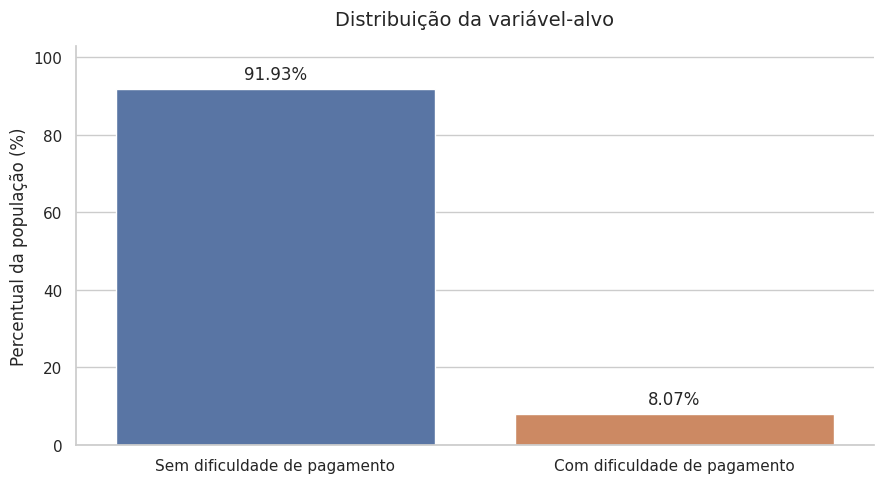

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=target_distribution,
    x="classe",
    y="percentual",
    hue="classe",
    legend=False,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
    )

ax.set_title(
    "Distribuição da variável-alvo",
    fontsize=14,
    pad=15,
)

ax.set_xlabel("")
ax.set_ylabel("Percentual da população (%)")
ax.set_ylim(
    0,
    target_distribution["percentual"].max() * 1.12,
)

sns.despine()
plt.tight_layout()

TARGET_DISTRIBUTION_FIGURE_PATH = (
    FIGURES_DIR / "target_distribution.png"
)

fig.savefig(
    TARGET_DISTRIBUTION_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [28]:
TARGET_DISTRIBUTION_TABLE_PATH = (
    TABLES_DIR / "target_distribution.csv"
)

target_distribution.to_csv(
    TARGET_DISTRIBUTION_TABLE_PATH,
    index=False,
)

print(
    "Tabela salva em: "
    f"{TARGET_DISTRIBUTION_TABLE_PATH}"
)

print(
    "Figura salva em: "
    f"{TARGET_DISTRIBUTION_FIGURE_PATH}"
)

Tabela salva em: /content/home-credit-default-risk/reports/tables/target_distribution.csv
Figura salva em: /content/home-credit-default-risk/reports/figures/target_distribution.png


### Interpretação

A população de desenvolvimento contém 307.511 solicitações, das quais 24.825
apresentaram dificuldade de pagamento. Isso corresponde a uma taxa observada de
evento de aproximadamente 8,07%.

A variável-alvo é, portanto, desbalanceada:

- aproximadamente 91,93% das solicitações pertencem à classe `0`;
- aproximadamente 8,07% pertencem à classe `1`.

Esse desbalanceamento torna a Accuracy inadequada como métrica principal. Um
classificador que previsse `TARGET = 0` para todos os clientes alcançaria cerca
de 91,93% de accuracy, apesar de não identificar nenhum cliente que apresentou
dificuldade de pagamento.

Por esse motivo, a avaliação priorizará métricas como ROC-AUC, Gini, KS,
PR-AUC, Log Loss e Brier Score, além da análise de calibração e da taxa
observada do evento por faixa de risco.

As divisões entre treino, validação e teste deverão preservar aproximadamente a
proporção da variável-alvo por meio de amostragem estratificada. Qualquer
tratamento adicional do desbalanceamento será realizado somente após a divisão
das amostras, evitando a transferência de informações entre os conjuntos.

## Dicionário de Dados

A competição fornece um dicionário com a descrição das variáveis presentes nas
diferentes tabelas.

Nesta etapa, o arquivo será carregado e validado para apoiar:

- a interpretação das variáveis;
- a identificação da tabela de origem;
- a análise da disponibilidade temporal;
- a investigação de possíveis fontes de data leakage;
- a documentação das variáveis utilizadas posteriormente nos modelos.

In [29]:
# Carregamento e limpeza inicial

COLUMNS_DESCRIPTION_PATH = (
    DATA_RAW_DIR / "HomeCredit_columns_description.csv"
)

columns_description = pd.read_csv(
    COLUMNS_DESCRIPTION_PATH,
    encoding="latin-1",
)

columns_description.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of t...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [37]:
# Remoção da coluna Auxiliar Unnamed: 0
unnamed_columns = [
    column
    for column in columns_description.columns
    if column.startswith("Unnamed:")
]

columns_description = columns_description.drop(
    columns=unnamed_columns,
)

print(
    f"Dimensões do dicionário: "
    f"{columns_description.shape[0]} linhas e "
    f"{columns_description.shape[1]} colunas"
)

display(columns_description.head())

Dimensões do dicionário: 219 linhas e 4 colunas


,Table,Row,Description,Special
0,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,application_{train|test}.csv,TARGET,Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of t...,NaN
2,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [31]:
# Validação da estrutura
expected_dictionary_columns = {
    "Table",
    "Row",
    "Description",
    "Special",
}

missing_dictionary_columns = (
    expected_dictionary_columns
    - set(columns_description.columns)
)

if missing_dictionary_columns:
    raise ValueError(
        "Colunas ausentes no dicionário: "
        + ", ".join(sorted(missing_dictionary_columns))
    )

assert columns_description["Table"].notna().all()
assert columns_description["Row"].notna().all()
assert columns_description["Description"].notna().all()

print("Estrutura do dicionário validada com sucesso.")

Estrutura do dicionário validada com sucesso.


In [32]:
# Quantidade de variáveis por fonte
dictionary_by_table = (
    columns_description
    .groupby("Table", as_index=False)
    .agg(
        variaveis=("Row", "count"),
        variaveis_unicas=("Row", "nunique"),
    )
    .sort_values(
        "variaveis",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(dictionary_by_table)

,Table,variaveis,variaveis_unicas
0,application_{train|test}.csv,122,122
1,previous_application.csv,38,38
2,credit_card_balance.csv,23,23
3,bureau.csv,17,17
4,POS_CASH_balance.csv,8,8
5,installments_payments.csv,8,8
6,bureau_balance.csv,3,3


In [33]:
# Dicionário das tabelas de aplicação
application_dictionary = (
    columns_description[
        columns_description["Table"]
        .str.contains(
            "application",
            case=False,
            na=False,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

display(application_dictionary.head(20))

,Table,Row,Description,Special
0,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,application_{train|test}.csv,TARGET,Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of t...,NaN
2,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
7,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


In [34]:
# Cobertura do dicionário
application_columns = set(
    application_train.columns
).union(
    application_test.columns
)

documented_application_columns = set(
    application_dictionary["Row"]
)

undocumented_application_columns = sorted(
    application_columns
    - documented_application_columns
)

dictionary_only_columns = sorted(
    documented_application_columns
    - application_columns
)

dictionary_coverage = pd.DataFrame(
    {
        "indicador": [
            "Variáveis presentes nas aplicações",
            "Variáveis documentadas",
            "Variáveis não documentadas",
            "Descrições sem variável correspondente",
        ],
        "quantidade": [
            len(application_columns),
            len(documented_application_columns),
            len(undocumented_application_columns),
            len(dictionary_only_columns),
        ],
    }
)

display(dictionary_coverage)

,indicador,quantidade
0,Variáveis presentes nas aplicações,122
1,Variáveis documentadas,152
2,Variáveis não documentadas,0
3,Descrições sem variável correspondente,30


In [35]:
# Mostrar eventuais divergências
print("Variáveis presentes na base e ausentes no dicionário:")
print(
    undocumented_application_columns
    if undocumented_application_columns
    else "Nenhuma"
)

print(
    "\nVariáveis descritas, mas não encontradas "
    "nas tabelas de aplicação:"
)

print(
    dictionary_only_columns
    if dictionary_only_columns
    else "Nenhuma"
)

Variáveis presentes na base e ausentes no dicionário:
Nenhuma

Variáveis descritas, mas não encontradas nas tabelas de aplicação:
['AMT_APPLICATION', 'AMT_DOWN_PAYMENT', 'CHANNEL_TYPE', 'CNT_PAYMENT', 'CODE_REJECT_REASON', 'DAYS_DECISION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_TERMINATION', 'FLAG_LAST_APPL_PER_CONTRACT', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CLIENT_TYPE', 'NAME_CONTRACT_STATUS', 'NAME_GOODS_CATEGORY', 'NAME_PAYMENT_TYPE', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'NAME_SELLER_INDUSTRY', 'NAME_YIELD_GROUP', 'NFLAG_INSURED_ON_APPROVAL', 'NFLAG_LAST_APPL_IN_DAY', 'NFLAG_MICRO_CASH', 'PRODUCT_COMBINATION', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'SELLERPLACE_AREA', 'SK_ID_PREV ']


In [36]:
# Persistência da versão limpa
CLEAN_DATA_DICTIONARY_PATH = (
    METADATA_DIR / "data_dictionary.csv"
)

columns_description.to_csv(
    CLEAN_DATA_DICTIONARY_PATH,
    index=False,
)

print(
    "Dicionário limpo salvo em: "
    f"{CLEAN_DATA_DICTIONARY_PATH}"
)

Dicionário limpo salvo em: /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata/data_dictionary.csv


## Caracterização Inicial das Variáveis

As colunas das tabelas de aplicação serão classificadas de acordo com:

- papel no projeto;
- tipo técnico;
- presença nas amostras da competição;
- quantidade de valores distintos;
- percentual de valores ausentes.

Essa caracterização produzirá um catálogo de variáveis que será reutilizado nas
etapas de análise exploratória, engenharia de variáveis e modelagem.

In [38]:
train_columns = set(application_train.columns)
test_columns = set(application_test.columns)

train_only_columns = sorted(
    train_columns - test_columns
)

test_only_columns = sorted(
    test_columns - train_columns
)

print("Colunas exclusivas de application_train:")
print(train_only_columns)

print("\nColunas exclusivas de application_test:")
print(
    test_only_columns
    if test_only_columns
    else "Nenhuma"
)

assert train_only_columns == ["TARGET"]
assert not test_only_columns

Colunas exclusivas de application_train:
['TARGET']

Colunas exclusivas de application_test:
Nenhuma


In [40]:
# Classificação das variáveis
def classify_variable_role(column_name: str) -> str:
    if column_name == "SK_ID_CURR":
        return "identificador"

    if column_name == "TARGET":
        return "variável-alvo"

    return "variável explicativa"


def classify_technical_type(dtype) -> str:
    if pd.api.types.is_numeric_dtype(dtype):
        return "numérica"

    if (
        pd.api.types.is_object_dtype(dtype)
        or pd.api.types.is_string_dtype(dtype)
        or isinstance(dtype, pd.CategoricalDtype)
    ):
        return "categórica"

    return "outro"

In [41]:
# Construção do catálogo
feature_catalog_records = []

for column in application_train.columns:
    train_series = application_train[column]

    feature_catalog_records.append(
        {
            "variavel": column,
            "papel": classify_variable_role(column),
            "tipo_pandas": str(train_series.dtype),
            "tipo_tecnico": classify_technical_type(
                train_series.dtype
            ),
            "presente_train": True,
            "presente_test": (
                column in application_test.columns
            ),
            "valores_unicos_train": (
                train_series.nunique(dropna=False)
            ),
            "missing_train_percentual": (
                train_series.isna().mean() * 100
            ),
            "missing_test_percentual": (
                application_test[column].isna().mean() * 100
                if column in application_test.columns
                else np.nan
            ),
        }
    )

feature_catalog = pd.DataFrame(
    feature_catalog_records
)

In [42]:
# Inclusão das descrições oficiais
application_descriptions = (
    application_dictionary[
        [
            "Row",
            "Description",
            "Special",
        ]
    ]
    .drop_duplicates(subset="Row")
    .rename(
        columns={
            "Row": "variavel",
            "Description": "descricao",
            "Special": "observacao_especial",
        }
    )
)

feature_catalog = feature_catalog.merge(
    application_descriptions,
    how="left",
    on="variavel",
)

In [43]:
# Resumo por papel e tipo
variable_type_summary = (
    feature_catalog
    .groupby(
        [
            "papel",
            "tipo_tecnico",
        ],
        as_index=False,
    )
    .agg(
        quantidade=("variavel", "count")
    )
)

display(variable_type_summary)

,papel,tipo_tecnico,quantidade
0,identificador,numérica,1
1,variável explicativa,categórica,16
2,variável explicativa,numérica,104
3,variável-alvo,numérica,1


In [44]:
# Resumo de missing values
missing_summary = pd.DataFrame(
    {
        "indicador": [
            "Total de variáveis",
            "Variáveis com missing no treino",
            "Variáveis sem missing no treino",
            "Variáveis com mais de 50% de missing",
            "Maior percentual de missing",
        ],
        "valor": [
            len(feature_catalog),
            (
                feature_catalog[
                    "missing_train_percentual"
                ] > 0
            ).sum(),
            (
                feature_catalog[
                    "missing_train_percentual"
                ] == 0
            ).sum(),
            (
                feature_catalog[
                    "missing_train_percentual"
                ] > 50
            ).sum(),
            feature_catalog[
                "missing_train_percentual"
            ].max(),
        ],
    }
)

display(missing_summary)

,indicador,valor
0,Total de variáveis,122.000000
1,Variáveis com missing no treino,67.000000
2,Variáveis sem missing no treino,55.000000
3,Variáveis com mais de 50% de missing,41.000000
4,Maior percentual de missing,69.872297


In [45]:
# Variáveis com maior missing
highest_missing_variables = (
    feature_catalog[
        feature_catalog["papel"]
        == "variável explicativa"
    ]
    .sort_values(
        "missing_train_percentual",
        ascending=False,
    )
    [
        [
            "variavel",
            "tipo_tecnico",
            "missing_train_percentual",
            "missing_test_percentual",
            "descricao",
        ]
    ]
    .head(20)
)

display(
    highest_missing_variables.style.format(
        {
            "missing_train_percentual": "{:.2f}%",
            "missing_test_percentual": "{:.2f}%",
        }
    )
)

,variavel,tipo_tecnico,missing_train_percentual,missing_test_percentual,descricao
48,COMMONAREA_AVG,numérica,69.87%,68.72%,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor"
62,COMMONAREA_MODE,numérica,69.87%,68.72%,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor"
76,COMMONAREA_MEDI,numérica,69.87%,68.72%,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor"
56,NONLIVINGAPARTMENTS_AVG,numérica,69.43%,68.41%,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor"
70,NONLIVINGAPARTMENTS_MODE,numérica,69.43%,68.41%,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor"
84,NONLIVINGAPARTMENTS_MEDI,numérica,69.43%,68.41%,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor"
86,FONDKAPREMONT_MODE,categórica,68.39%,67.28%,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor"
54,LIVINGAPARTMENTS_AVG,numérica,68.35%,67.25%,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor"
82,LIVINGAPARTMENTS_MEDI,numérica,68.35%,67.25%,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor"
68,LIVINGAPARTMENTS_MODE,numérica,68.35%,67.25%,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor"


### Observação sobre as variáveis do imóvel

As variáveis com maior percentual de missing estão concentradas principalmente
em informações normalizadas sobre o imóvel onde o cliente reside.

O dicionário da Home Credit utiliza uma descrição compartilhada para diferentes
características da construção, como área dos apartamentos, área comum, área
habitável, idade do imóvel, elevadores, entradas e quantidade de andares.

Essas características aparecem em versões com os sufixos `_AVG`, `_MODE` e
`_MEDI`, correspondentes, respectivamente, às representações por média, moda e
mediana utilizadas pela fonte.

O elevado percentual de missing não implica remoção automática. A ausência pode
ser estrutural, informativa ou decorrente da indisponibilidade da informação.
Seu tratamento será definido após a análise da relação entre missing, variável-
alvo, estabilidade e contribuição preditiva.

In [46]:
# Verificação de variáveis constantes
constant_variables = (
    feature_catalog[
        (
            feature_catalog["valores_unicos_train"]
            <= 1
        )
        & (
            feature_catalog["papel"]
            == "variável explicativa"
        )
    ]["variavel"]
    .tolist()
)

print("Variáveis constantes:")
print(
    constant_variables
    if constant_variables
    else "Nenhuma"
)

Variáveis constantes:
Nenhuma


In [47]:
# Verificação de valores infinitos
numeric_feature_columns = (
    feature_catalog[
        (
            feature_catalog["tipo_tecnico"]
            == "numérica"
        )
        & (
            feature_catalog["papel"]
            == "variável explicativa"
        )
    ]["variavel"]
    .tolist()
)

infinite_counts = (
    np.isinf(
        application_train[
            numeric_feature_columns
        ]
    )
    .sum()
)

infinite_variables = (
    infinite_counts[
        infinite_counts > 0
    ]
    .sort_values(ascending=False)
)

print("Variáveis com valores infinitos:")

if infinite_variables.empty:
    print("Nenhuma")
else:
    display(
        infinite_variables
        .rename("quantidade")
        .reset_index()
        .rename(columns={"index": "variavel"})
    )

Variáveis com valores infinitos:
Nenhuma


In [48]:
# Persistência do catálogo
FEATURE_CATALOG_PATH = (
    METADATA_DIR / "application_feature_catalog.csv"
)

feature_catalog.to_csv(
    FEATURE_CATALOG_PATH,
    index=False,
)

print(
    f"Catálogo salvo em: {FEATURE_CATALOG_PATH}"
)

Catálogo salvo em: /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata/application_feature_catalog.csv


## Verificações Iniciais de Qualidade

Além de missing values, serão verificadas duplicidades e ocorrências que possam
representar valores sentinela, categorias inválidas ou inconsistências
semânticas.

Esta etapa não realizará ainda o tratamento dos dados. Seu objetivo é registrar
os problemas que deverão ser investigados no notebook de EDA.

In [49]:
# Duplicidade de registros
duplicate_rows = application_train.duplicated().sum()

duplicate_application_ids = (
    application_train["SK_ID_CURR"]
    .duplicated()
    .sum()
)

print(f"Linhas completamente duplicadas: {duplicate_rows}")
print(
    "Identificadores SK_ID_CURR duplicados: "
    f"{duplicate_application_ids}"
)

Linhas completamente duplicadas: 0
Identificadores SK_ID_CURR duplicados: 0


In [50]:
# Valores sentinela em DAYS_EMPLOYED

# A variável representa o tempo entre o início do emprego e a solicitação, medido em dias. Ela contém o valor conhecido 365243,
# equivalente a aproximadamente mil anos e, portanto, impossível de ser interpretado literalmente.

DAYS_EMPLOYED_SENTINEL = 365243

days_employed_sentinel_count = (
    application_train["DAYS_EMPLOYED"]
    .eq(DAYS_EMPLOYED_SENTINEL)
    .sum()
)

days_employed_sentinel_percentage = (
    days_employed_sentinel_count
    / len(application_train)
    * 100
)

print(
    "Ocorrências de DAYS_EMPLOYED = 365243: "
    f"{days_employed_sentinel_count:,}"
)

print(
    "Percentual da população: "
    f"{days_employed_sentinel_percentage:.2f}%"
)

Ocorrências de DAYS_EMPLOYED = 365243: 55,374
Percentual da população: 18.01%


In [51]:
# Categorias especiais em CODE_GENDER
gender_distribution = (
    application_train["CODE_GENDER"]
    .value_counts(
        dropna=False,
    )
    .rename_axis("CODE_GENDER")
    .reset_index(name="quantidade")
)

gender_distribution["percentual"] = (
    gender_distribution["quantidade"]
    / len(application_train)
    * 100
)

display(
    gender_distribution.style.format(
        {
            "quantidade": "{:,.0f}",
            "percentual": "{:.4f}%",
        }
    )
)

,CODE_GENDER,quantidade,percentual
0,F,"202,448",65.8344%
1,M,"105,059",34.1643%
2,XNA,4,0.0013%


In [52]:
# Coerência de algumas variáveis básicas
quality_checks = pd.DataFrame(
    [
        {
            "verificacao": "DAYS_BIRTH maior ou igual a zero",
            "quantidade": (
                application_train["DAYS_BIRTH"] >= 0
            ).sum(),
        },
        {
            "verificacao": "AMT_INCOME_TOTAL menor ou igual a zero",
            "quantidade": (
                application_train["AMT_INCOME_TOTAL"] <= 0
            ).sum(),
        },
        {
            "verificacao": "AMT_CREDIT menor ou igual a zero",
            "quantidade": (
                application_train["AMT_CREDIT"] <= 0
            ).sum(),
        },
        {
            "verificacao": "AMT_ANNUITY menor ou igual a zero",
            "quantidade": (
                application_train["AMT_ANNUITY"] <= 0
            ).sum(),
        },
        {
            "verificacao": "CNT_FAM_MEMBERS menor ou igual a zero",
            "quantidade": (
                application_train["CNT_FAM_MEMBERS"] <= 0
            ).sum(),
        },
        {
            "verificacao": "TARGET ausente",
            "quantidade": (
                application_train["TARGET"]
                .isna()
                .sum()
            ),
        },
    ]
)

display(quality_checks)

,verificacao,quantidade
0,DAYS_BIRTH maior ou igual a zero,0
1,AMT_INCOME_TOTAL menor ou igual a zero,0
2,AMT_CREDIT menor ou igual a zero,0
3,AMT_ANNUITY menor ou igual a zero,0
4,CNT_FAM_MEMBERS menor ou igual a zero,0
5,TARGET ausente,0


In [53]:
# Registro consolidado
initial_quality_summary = pd.DataFrame(
    [
        {
            "item": "Linhas duplicadas",
            "quantidade": duplicate_rows,
            "acao_preliminar": "Nenhuma se o resultado for zero",
        },
        {
            "item": "SK_ID_CURR duplicado",
            "quantidade": duplicate_application_ids,
            "acao_preliminar": "Investigar se diferente de zero",
        },
        {
            "item": "Sentinela em DAYS_EMPLOYED",
            "quantidade": days_employed_sentinel_count,
            "acao_preliminar": (
                "Converter em missing e criar flag indicadora"
            ),
        },
        {
            "item": "Categoria XNA em CODE_GENDER",
            "quantidade": (
                application_train["CODE_GENDER"]
                .eq("XNA")
                .sum()
            ),
            "acao_preliminar": (
                "Investigar e definir tratamento na EDA"
            ),
        },
    ]
)

display(initial_quality_summary)

,item,quantidade,acao_preliminar
0,Linhas duplicadas,0,Nenhuma se o resultado for zero
1,SK_ID_CURR duplicado,0,Investigar se diferente de zero
2,Sentinela em DAYS_EMPLOYED,55374,Converter em missing e criar flag indicadora
3,Categoria XNA em CODE_GENDER,4,Investigar e definir tratamento na EDA


## Conclusões e Decisões Metodológicas

Este notebook estabeleceu a base conceitual e estrutural do projeto de
Application Score.

### Principais constatações

- A unidade de análise é uma solicitação de crédito identificada por
  `SK_ID_CURR`.
- `application_train` contém 307.511 solicitações e 122 colunas.
- `application_test` contém 48.744 solicitações e 121 colunas.
- A diferença entre as tabelas é a presença de `TARGET` somente em
  `application_train`.
- Não foram identificados valores ausentes ou duplicados em `SK_ID_CURR`.
- Os identificadores de `application_train` e `application_test` não se
  sobrepõem.
- A variável-alvo é binária e não possui valores ausentes.
- A taxa observada de dificuldade de pagamento é de aproximadamente 8,07%,
  caracterizando um problema desbalanceado.
- A base possui múltiplas fontes históricas com diferentes granularidades e
  relacionamentos de um para muitos.
- As tabelas históricas deverão ser agregadas no nível de `SK_ID_CURR` antes de
  serem integradas à base principal.
- Os missing values estão concentrados principalmente em informações sobre
  imóveis, fontes externas e características que podem não estar disponíveis
  para todos os clientes.
- `DAYS_EMPLOYED` contém o valor sentinela `365243`, que não representa um tempo
  de emprego válido.
- `CODE_GENDER` contém uma quantidade residual de registros com a categoria
  especial `XNA`.

### Decisões metodológicas

1. Os arquivos originais serão preservados sem alterações no diretório `raw`.

2. `application_test` será utilizado somente para demonstrar a geração de
   previsões no formato da competição. Ele não será utilizado na avaliação dos
   modelos porque não possui o evento observado.

3. As amostras de treino, validação e teste serão construídas posteriormente a
   partir de `application_train`, utilizando divisão estratificada.

4. A divisão não será apresentada como Out-of-Time, pois a base não possui uma
   referência temporal confiável para as aplicações atuais.

5. Nenhum tratamento supervisionado, resampling, binning, imputação ou seleção
   de variáveis será ajustado antes da separação das amostras.

6. Variáveis com elevado percentual de missing não serão removidas
   automaticamente. A decisão considerará disponibilidade, interpretação,
   relação com o evento, estabilidade e contribuição preditiva.

7. O valor `365243` de `DAYS_EMPLOYED` será posteriormente convertido em
   missing e acompanhado por uma flag indicadora da anomalia.

8. A categoria `XNA` de `CODE_GENDER` será investigada antes da definição do
   tratamento.

9. Informações históricas serão avaliadas quanto à disponibilidade temporal para
   prevenir data leakage.

10. Accuracy não será utilizada como métrica principal devido ao
    desbalanceamento da variável-alvo.

11. A avaliação priorizará discriminação, calibração, estabilidade,
    interpretabilidade e impacto sobre indicadores de negócio.

12. Os dados intermediários e artefatos serão armazenados no cache, mas poderão
    ser reconstruídos a partir dos dados originais e dos notebooks.

In [54]:
# Registro das decisões
project_definition = {
    "project_name": "Home Credit Default Risk",
    "model_type": "Application Score PF",
    "analysis_unit": "Solicitação de crédito",
    "primary_key": "SK_ID_CURR",
    "target": "TARGET",
    "target_event": 1,
    "target_non_event": 0,
    "target_interpretation": (
        "Dificuldade de pagamento conforme definição "
        "da Home Credit"
    ),
    "development_source": "application_train.csv",
    "competition_scoring_source": "application_test.csv",
    "validation_strategy": (
        "Treino, validação e teste estratificados"
    ),
    "genuine_out_of_time_validation": False,
    "random_state": RANDOM_STATE,
    "models": [
        "Logistic Regression com WoE",
        "LightGBM challenger",
    ],
    "primary_evaluation_dimensions": [
        "discriminação",
        "calibração",
        "estabilidade",
        "interpretabilidade",
        "impacto de negócio",
    ],
}

PROJECT_DEFINITION_PATH = (
    METADATA_DIR / "project_definition.json"
)

with open(
    PROJECT_DEFINITION_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        project_definition,
        file,
        ensure_ascii=False,
        indent=4,
    )

print(
    "Definição do projeto salva em: "
    f"{PROJECT_DEFINITION_PATH}"
)

Definição do projeto salva em: /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata/project_definition.json


## Próxima Etapa

O próximo notebook realizará a análise exploratória detalhada de
`application_train`, com foco em:

- missing values;
- variáveis categóricas;
- distribuições numéricas;
- outliers e anomalias;
- relação das variáveis com `TARGET`;
- disponibilidade temporal;
- possíveis fontes de data leakage;
- diferenças relevantes entre as populações de desenvolvimento e da
  competição.

O tratamento dos dados será definido somente após essa investigação.